In [50]:
#Load the dataset

import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv("/content/drive/My Drive/DS/Time_series_forecasting/Company_stock_prices.csv")
print(df.head())

print(df.head())
print(df.shape)
print(df.columns)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
         Date        Open        High         Low       Close   Adj Close  \
0  19-10-2020  537.070007  541.799988  525.380005  530.719971  530.719971   
1  20-10-2020  528.140015  533.780029  522.260010  525.419983  525.419983   
2  21-10-2020  501.029999  506.850006  488.250000  489.049988  489.049988   
3  22-10-2020  494.690002  495.140015  482.000000  485.230011  485.230011   
4  23-10-2020  488.109985  490.059998  481.350006  488.279999  488.279999   

     Volume  
0   7567500  
1  10047200  
2  17405700  
3   6997900  
4   4927900  
         Date        Open        High         Low       Close   Adj Close  \
0  19-10-2020  537.070007  541.799988  525.380005  530.719971  530.719971   
1  20-10-2020  528.140015  533.780029  522.260010  525.419983  525.419983   
2  21-10-2020  501.029999  506.850006  488.250000  489.049988  489.049988   
3  22-10-2020  4

In [51]:
#Convert Date

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print(df.head())
print(df.tail())

        Date        Open        High         Low       Close   Adj Close  \
0 2020-10-19  537.070007  541.799988  525.380005  530.719971  530.719971   
1 2020-10-20  528.140015  533.780029  522.260010  525.419983  525.419983   
2 2020-10-21  501.029999  506.850006  488.250000  489.049988  489.049988   
3 2020-10-22  494.690002  495.140015  482.000000  485.230011  485.230011   
4 2020-10-23  488.109985  490.059998  481.350006  488.279999  488.279999   

     Volume  
0   7567500  
1  10047200  
2  17405700  
3   6997900  
4   4927900  
          Date        Open        High         Low       Close   Adj Close  \
748 2023-10-10  385.579987  388.700012  372.250000  373.320007  373.320007   
749 2023-10-11  372.779999  377.809998  365.339996  365.929993  365.929993   
750 2023-10-12  366.480011  368.829987  359.049988  361.200012  361.200012   
751 2023-10-13  355.640015  358.929993  352.049988  355.679993  355.679993   
752 2023-10-16  356.209991  363.079987  354.769989  360.820007  360.8

In [52]:
#Verify the date range
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

Start Date: 2020-10-19 00:00:00
End Date: 2023-10-16 00:00:00


In [53]:
#Check missing values
print(df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [54]:
#Check duplicate dates
print("Duplicate dates:", df["Date"].duplicated().sum())

Duplicate dates: 0


In [55]:
ohlc_columns = [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume"
]

df = df[ohlc_columns]

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       753 non-null    datetime64[ns]
 1   Open       753 non-null    float64       
 2   High       753 non-null    float64       
 3   Low        753 non-null    float64       
 4   Close      753 non-null    float64       
 5   Adj Close  753 non-null    float64       
 6   Volume     753 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 41.3 KB
None
                                Date        Open        High         Low  \
count                            753  753.000000  753.000000  753.000000   
mean   2022-04-17 10:23:25.577689344  414.903107  421.117954  408.519270   
min              2020-10-19 00:00:00  163.960007  172.059998  162.710007   
25%              2021-07-20 00:00:00  311.570007  319.799988  308.850006   
50%              2

# Data Preprocessing & Train-Test Splitting

In [56]:
#Check data types
print(df.dtypes)

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object


Check OHLC consistency

For every trading day:

High should be ≥ Open and Close

Low should be ≤ Open and Close

In [57]:
print("High < Open:",
      (df["High"] < df["Open"]).sum())

print("High < Close:",
      (df["High"] < df["Close"]).sum())

print("Low > Open:",
      (df["Low"] > df["Open"]).sum())

print("Low > Close:",
      (df["Low"] > df["Close"]).sum())

High < Open: 0
High < Close: 0
Low > Open: 0
Low > Close: 0


In [58]:
#Remove duplicates
df = df.drop_duplicates(subset=["Date"])

In [59]:
#Create the training and test sets
train = df[df["Date"] < "2023-01-01"].copy()

test = df[df["Date"] >= "2023-01-01"].copy()

print("Training:")
print(train["Date"].min(), "to", train["Date"].max())
print("Rows:", len(train))

print("\nTesting:")
print(test["Date"].min(), "to", test["Date"].max())
print("Rows:", len(test))

Training:
2020-10-19 00:00:00 to 2022-12-30 00:00:00
Rows: 555

Testing:
2023-01-03 00:00:00 to 2023-10-16 00:00:00
Rows: 198


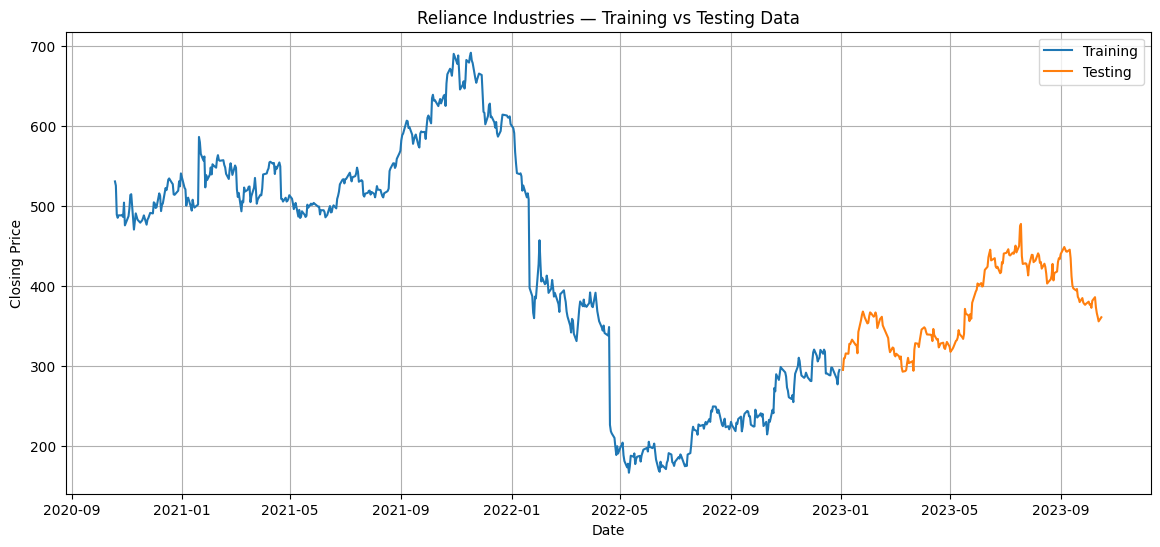

In [60]:
#Visualize the split
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(train["Date"], train["Close"], label="Training")
plt.plot(test["Date"], test["Close"], label="Testing")

plt.title("Reliance Industries — Training vs Testing Data")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

#EDA & Trend Identification

Start with Closing Price

The first thing we want to understand is how Reliance's price moved over time.

| Analysis          | Feature                  |
| ----------------- | ------------------------ |
| Price trend       | `Close`                  |
| Daily movement    | `Daily_Return`           |
| Short-term trend  | `MA_20`                  |
| Long-term trend   | `MA_200`                 |
| Volatility        | `Volatility_20`          |
| Market activity   | `Volume`                 |
| Extreme movements | Largest absolute returns |

workflow

Closing Price─────→Daily Returns─────→20-Day MA  (Short-Term Trend)─────→200-Day MA(Long-Term Trend)─────→20-Day Volatility─────→Volume Analysis─────→Major Price Movements─────→External Event Investigation

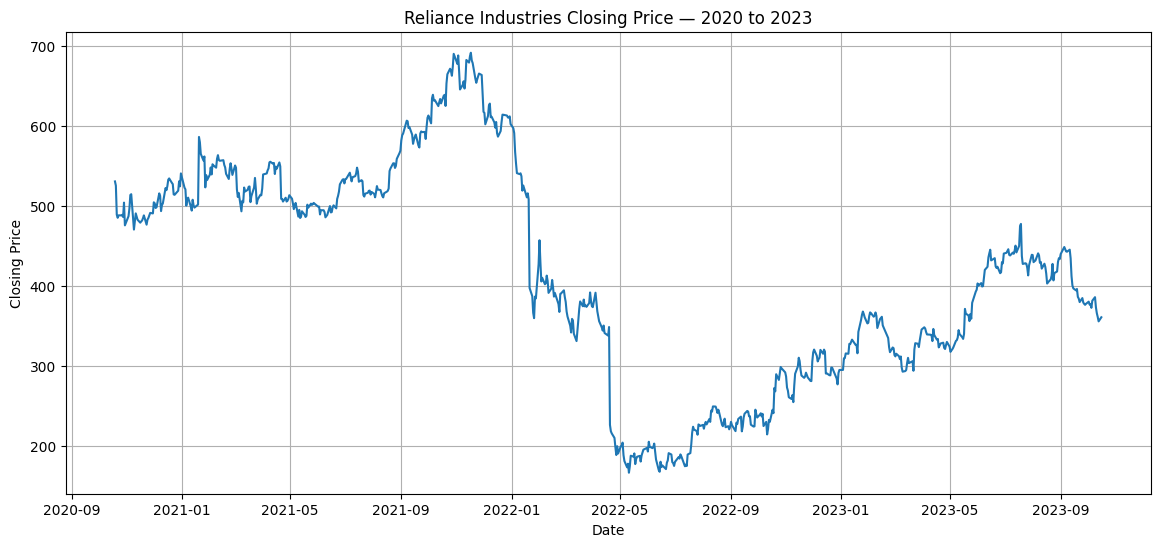

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"])

plt.title("Reliance Industries Closing Price — 2020 to 2023")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid(True)
plt.show()

Calculate Daily Returns

Price alone doesn't tell us how volatile the stock is.

        Date       Close  Daily_Return
0 2020-10-19  530.719971           NaN
1 2020-10-20  525.419983     -0.998641
2 2020-10-21  489.049988     -6.922081
3 2020-10-22  485.230011     -0.781102
4 2020-10-23  488.279999      0.628565
5 2020-10-26  488.239990     -0.008194
6 2020-10-27  488.929993      0.141325
7 2020-10-28  486.239990     -0.550182
8 2020-10-29  504.209991      3.695706
9 2020-10-30  475.739990     -5.646457


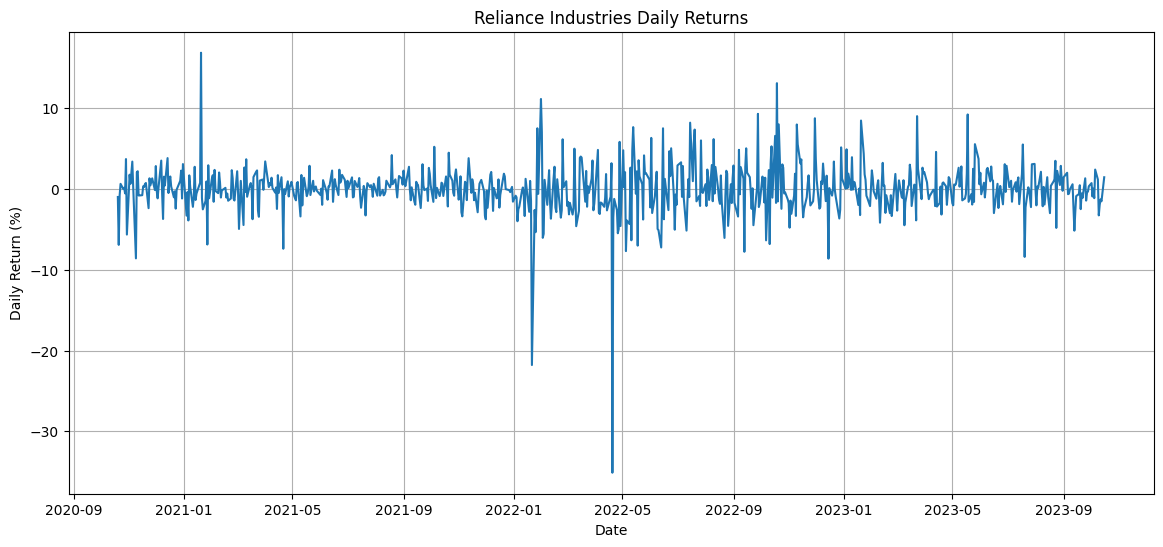

In [62]:
#Create daily percentage returns:
df["Daily_Return"] = df["Close"].pct_change() * 100

#View the result:
print(df[["Date", "Close", "Daily_Return"]].head(10))

#Plot
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Daily_Return"])

plt.title("Reliance Industries Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")

plt.grid(True)
plt.show()

Short-Term Trend — Moving Average

We'll use a 20-day moving average to represent approximately one trading month.

When:

Close > MA20

→ short-term price is generally stronger.

When:

Close < MA20

→ short-term price is generally weaker.

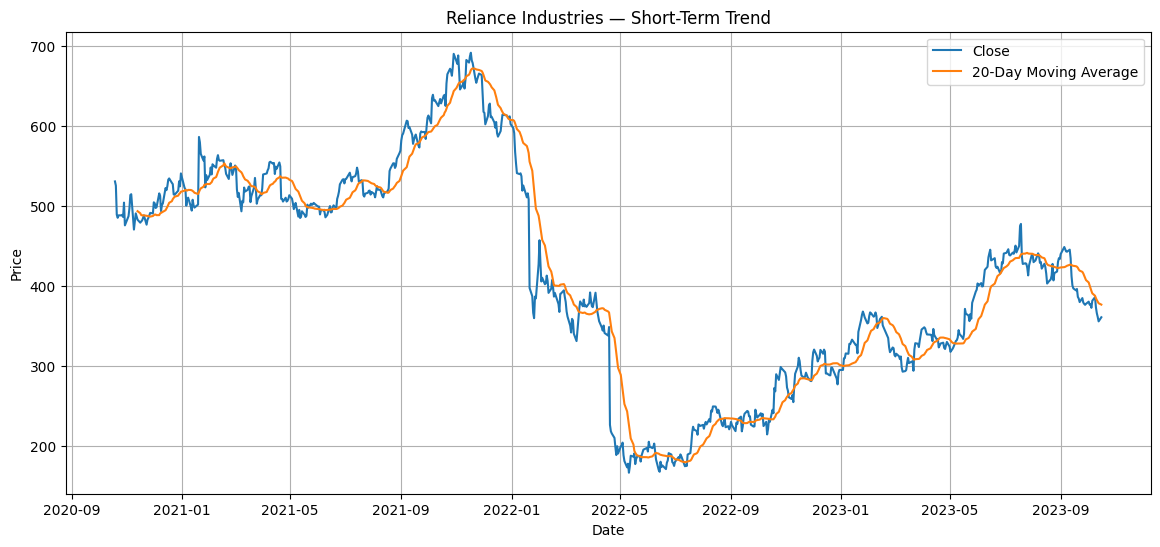

In [63]:
df["MA_20"] = df["Close"].rolling(window=20).mean()

#Plot
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA_20"], label="20-Day Moving Average")

plt.title("Reliance Industries — Short-Term Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

Long-Term Trend — 200-Day Moving Average

Now create a 200-day moving average.

Why 200 days?

A stock typically has around 250 trading sessions per year.

Therefore, a 200-day moving average gives us a useful approximation of the long-term market trend.

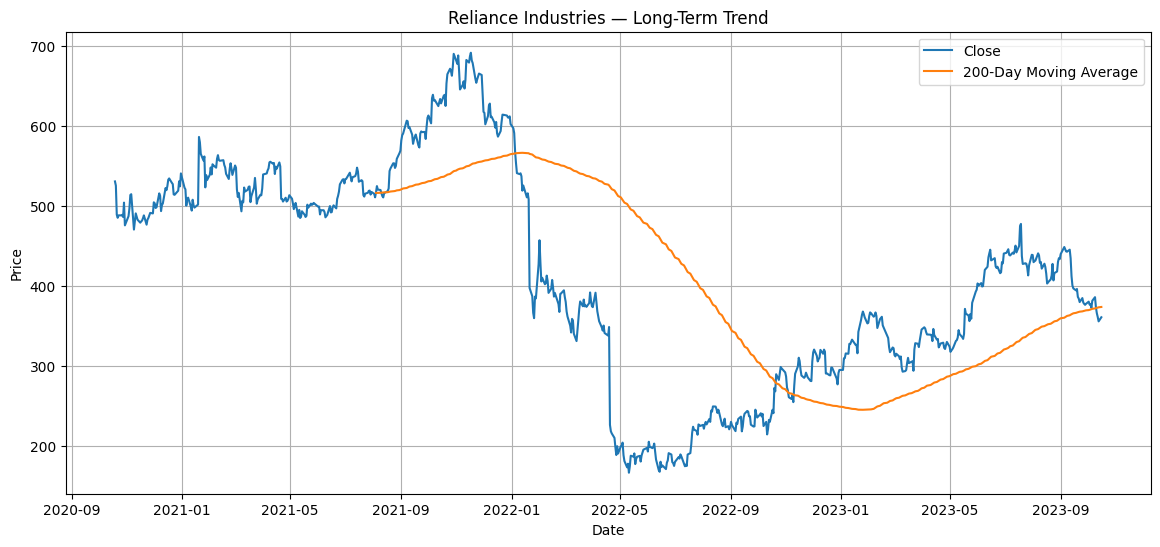

In [64]:
#create a 200-day moving average
df["MA_200"] = df["Close"].rolling(window=200).mean()

#Plot
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA_200"], label="200-Day Moving Average")

plt.title("Reliance Industries — Long-Term Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

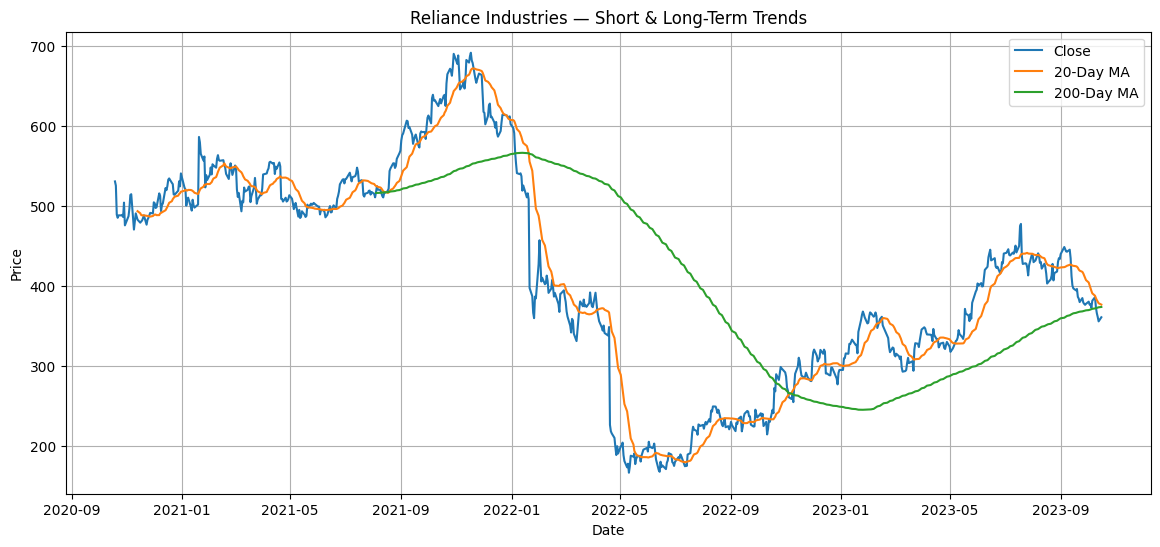

In [65]:
#Short-Term + Long-Term Together

plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA_20"], label="20-Day MA")
plt.plot(df["Date"], df["MA_200"], label="200-Day MA")

plt.title("Reliance Industries — Short & Long-Term Trends")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()

Volatility Analysis

Interpretation

Higher volatility:

→ larger price fluctuations
→ greater uncertainty

Lower volatility:

→ relatively stable price movement.

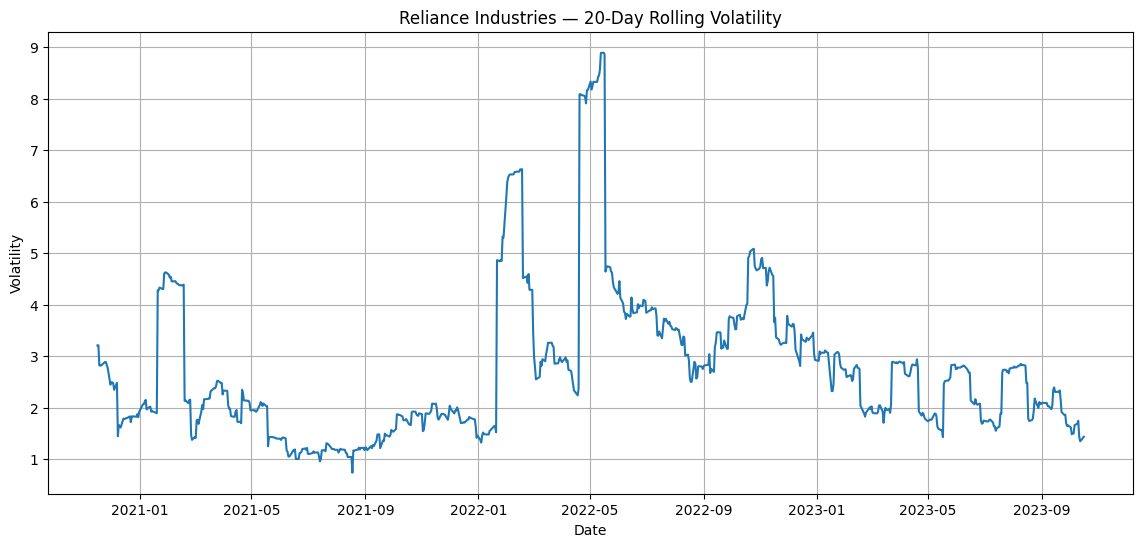

In [66]:
#Now calculate rolling volatility.
df["Volatility_20"] = df["Daily_Return"].rolling(window=20).std()

#Plot:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Volatility_20"])

plt.title("Reliance Industries — 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(True)
plt.show()

Trading Volume

Trading volume in stocks refers to the total number of shares or contracts of a particular stock that are bought and sold during a specific period, such as a day, week, or month.

our dataset contains Volume, so we should examine it.

We can later compare large volume spikes with large price movements.

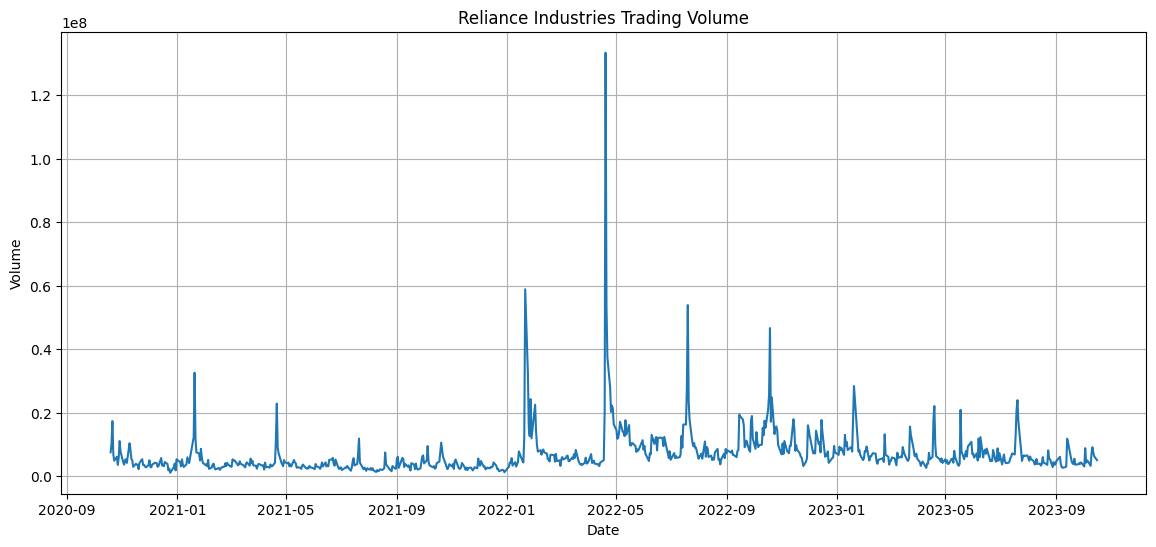

In [67]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Volume"])

plt.title("Reliance Industries Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.grid(True)
plt.show()

#Identify Major Price-Movement Days

This is important because these dates become candidates for our external-event investigation.

In [68]:
#find the days where the stock moved the most
largest_moves = df.loc[
    df["Daily_Return"].abs().nlargest(10).index,
    ["Date", "Open", "High", "Low", "Close", "Daily_Return", "Volume"]
]

print(largest_moves.sort_values("Date"))

          Date        Open        High         Low       Close  Daily_Return  \
63  2021-01-20  565.419983  593.289978  556.859985  586.340027     16.854344   
317 2022-01-21  400.429993  409.149994  379.989990  397.500000    -21.790457   
323 2022-01-31  401.970001  427.700012  398.200012  427.140015     11.130199   
378 2022-04-20  245.199997  248.699997  212.509995  226.190002    -35.116603   
489 2022-09-28  229.690002  246.649994  227.380005  245.199997      9.288641   
504 2022-10-19  265.000000  279.299988  262.660004  272.380005     13.086442   
533 2022-11-30  281.369995  308.260010  280.410004  305.529999      8.745020   
544 2022-12-15  302.119995  303.390015  286.549988  290.410004     -8.627249   
610 2023-03-23  304.679993  322.779999  304.140015  320.369995      9.006465   
649 2023-05-18  347.250000  375.869995  346.369995  371.290009      9.215796   

        Volume  
63    32637500  
317   58904300  
323   20047500  
378  133387500  
489   17579700  
504   46685300  


#External Events

This is important because these are the dates we should investigate, rather than choosing events arbitrarily.

| Period | External factor                    | Potential effect on RIL                      |
| ------ | ---------------------------------- | -------------------------------------------- |
| 2020   | COVID-19 / lockdown                | Negative market & oil shock                  |
| 2020   | Jio investments                    | Positive sentiment / business transformation |
| 2022   | Russia-Ukraine / high crude prices | Major energy-market impact                   |
| 2022   | Windfall tax introduction          | Negative for oil/refining sentiment          |
| 2022   | Windfall tax reduction             | Positive reaction                            |
| 2023   | Jio Financial Services demerger    | Corporate restructuring / price adjustment   |


In [69]:
#find the biggest movements

largest_moves = df.loc[
    df["Daily_Return"].abs().nlargest(15).index,
    ["Date", "Open", "High", "Low", "Close", "Daily_Return", "Volume"]
]

largest_moves = largest_moves.sort_values("Date")

print(largest_moves.to_string(index=False))

largest_moves = df.loc[
    df["Daily_Return"].abs().nlargest(15).index,
    ["Date", "Open", "High", "Low", "Close", "Daily_Return", "Volume"]
]

print(largest_moves.sort_values("Date").to_string(index=False))

      Date       Open       High        Low      Close  Daily_Return    Volume
2020-11-09 485.540009 495.850006 467.260010 470.500000     -8.592851  10419700
2021-01-20 565.419983 593.289978 556.859985 586.340027     16.854344  32637500
2022-01-21 400.429993 409.149994 379.989990 397.500000    -21.790457  58904300
2022-01-31 401.970001 427.700012 398.200012 427.140015     11.130199  20047500
2022-04-20 245.199997 248.699997 212.509995 226.190002    -35.116603 133387500
2022-07-15 175.580002 189.220001 174.559998 189.110001      8.198880  16319100
2022-09-28 229.690002 246.649994 227.380005 245.199997      9.288641  17579700
2022-10-19 265.000000 279.299988 262.660004 272.380005     13.086442  46685300
2022-10-21 268.950012 290.750000 265.679993 289.570007      7.984040  24889100
2022-11-30 281.369995 308.260010 280.410004 305.529999      8.745020  16070100
2022-12-15 302.119995 303.390015 286.549988 290.410004     -8.627249  17724600
2023-01-20 336.790009 344.000000 332.630005 342.5000

#Validate suspicious price movements

This will show approximately 5 calendar days before and after each event.



In [70]:
#Check prices around each suspicious date
suspicious_dates = [
    "2022-01-21",
    "2022-04-20",
    "2023-07-20"
]

for date in suspicious_dates:
    print(f"\n{'='*60}")
    print(f"Data around {date}")
    print(f"{'='*60}")

    target_date = pd.to_datetime(date)

    result = df[
        (df["Date"] >= target_date - pd.Timedelta(days=5)) &
        (df["Date"] <= target_date + pd.Timedelta(days=5))
    ][["Date", "Open", "High", "Low", "Close", "Daily_Return"]]

    print(result.to_string(index=False))


Data around 2022-01-21
      Date       Open       High        Low      Close  Daily_Return
2022-01-18 520.080017 521.750000 508.679993 510.799988     -2.832470
2022-01-19 515.000000 523.210022 510.510010 515.859985      0.990602
2022-01-20 517.750000 526.640015 506.929993 508.250000     -1.475204
2022-01-21 400.429993 409.149994 379.989990 397.500000    -21.790457
2022-01-24 383.910004 387.260010 351.459991 387.149994     -2.603775
2022-01-25 379.140015 387.709991 365.130005 366.420013     -5.354509
2022-01-26 378.269989 382.660004 356.619995 359.700012     -1.833961

Data around 2022-04-20
      Date       Open       High        Low      Close  Daily_Return
2022-04-18 340.000000 342.359985 331.619995 337.859985     -0.958585
2022-04-19 333.220001 351.679993 333.220001 348.609985      3.181791
2022-04-20 245.199997 248.699997 212.509995 226.190002    -35.116603
2022-04-21 220.000000 227.679993 211.520004 218.220001     -3.523587
2022-04-22 220.179993 226.270004 210.050003 215.520004 

      Date      Close  Daily_Return    Volume
2021-01-20 586.340027     16.854344  32637500
2022-01-21 397.500000    -21.790457  58904300
2022-01-31 427.140015     11.130199  20047500
2022-04-20 226.190002    -35.116603 133387500
2022-10-19 272.380005     13.086442  46685300
      Date      Close  Close_Ratio  Daily_Return
2021-01-20 586.340027     1.168543     16.854344
2022-01-21 397.500000     0.782095    -21.790457
2022-01-31 427.140015     1.111302     11.130199
2022-04-20 226.190002     0.648834    -35.116603
2022-10-19 272.380005     1.130864     13.086442


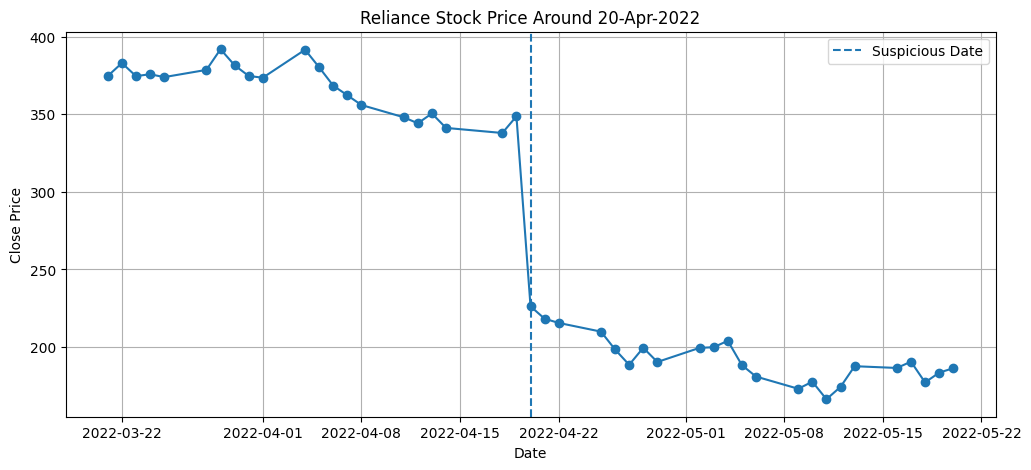

In [71]:
#Check for extreme daily returns

extreme_moves = df[
    df["Daily_Return"].abs() > 10
][["Date", "Close", "Daily_Return", "Volume"]]

print(extreme_moves.to_string(index=False))

#Calculate the Close-to-Close price ratio

df["Close_Ratio"] = df["Close"] / df["Close"].shift(1)

print(
    df.loc[
        df["Daily_Return"].abs() > 10,
        ["Date", "Close", "Close_Ratio", "Daily_Return"]
    ].to_string(index=False)
)

#Visualize the suspicious periods


import matplotlib.pyplot as plt

date = pd.to_datetime("2022-04-20")

window = df[
    (df["Date"] >= date - pd.Timedelta(days=30)) &
    (df["Date"] <= date + pd.Timedelta(days=30))
]

plt.figure(figsize=(12, 5))

plt.plot(window["Date"], window["Close"], marker="o")

plt.axvline(date, linestyle="--", label="Suspicious Date")

plt.title("Reliance Stock Price Around 20-Apr-2022")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)

plt.show()

date = pd.to_datetime("2022-01-21")
date = pd.to_datetime("2023-07-20")
date = pd.to_datetime("2023-04-20")

In [72]:
#preserve the original data and create a validation flag.

df["Extreme_Movement"] = df["Daily_Return"].abs() > 10

#auditable record of unusual observations.

print(
    df[df["Extreme_Movement"]][
        ["Date", "Close", "Daily_Return", "Volume"]
    ].to_string(index=False)
)

#compare the raw OHLC sequence immediately before and after the dates.

for date in ["2022-01-21", "2022-04-20"]:

    target = pd.to_datetime(date)

    print("\n" + "=" * 70)
    print(f"PRICE DATA AROUND {date}")
    print("=" * 70)

    print(
        df[
            (df["Date"] >= target - pd.Timedelta(days=3)) &
            (df["Date"] <= target + pd.Timedelta(days=3))
        ][
            ["Date", "Open", "High", "Low", "Close", "Volume"]
        ].to_string(index=False)
    )

      Date      Close  Daily_Return    Volume
2021-01-20 586.340027     16.854344  32637500
2022-01-21 397.500000    -21.790457  58904300
2022-01-31 427.140015     11.130199  20047500
2022-04-20 226.190002    -35.116603 133387500
2022-10-19 272.380005     13.086442  46685300

PRICE DATA AROUND 2022-01-21
      Date       Open       High        Low      Close   Volume
2022-01-18 520.080017 521.750000 508.679993 510.799988  4839100
2022-01-19 515.000000 523.210022 510.510010 515.859985  4353500
2022-01-20 517.750000 526.640015 506.929993 508.250000 12659000
2022-01-21 400.429993 409.149994 379.989990 397.500000 58904300
2022-01-24 383.910004 387.260010 351.459991 387.149994 32346000

PRICE DATA AROUND 2022-04-20
      Date       Open       High        Low      Close    Volume
2022-04-18 340.000000 342.359985 331.619995 337.859985   5105000
2022-04-19 333.220001 351.679993 333.220001 348.609985  20906900
2022-04-20 245.199997 248.699997 212.509995 226.190002 133387500
2022-04-21 220.00000

Why are we checking this?

We want to see whether:

Close

and

Adj Close

behave differently around these discontinuities.

In [73]:
df[
    df["Date"].isin(
        pd.to_datetime([
            "2022-01-20",
            "2022-01-21",
            "2022-04-19",
            "2022-04-20",
            "2022-07-19",
            "2022-07-20"
        ])
    )
][
    ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]
].to_string(index=False)

'      Date       Open       High        Low      Close  Adj Close    Volume\n2022-01-20 517.750000 526.640015 506.929993 508.250000 508.250000  12659000\n2022-01-21 400.429993 409.149994 379.989990 397.500000 397.500000  58904300\n2022-04-19 333.220001 351.679993 333.220001 348.609985 348.609985  20906900\n2022-04-20 245.199997 248.699997 212.509995 226.190002 226.190002 133387500\n2022-07-19 193.020004 201.970001 188.399994 201.630005 201.630005  28178700\n2022-07-20 208.169998 216.970001 200.100006 216.440002 216.440002  53920300'

#Important observations

|20-Jan-2021: +16.85%|
|21-Jan-2022: −21.79%|
|20-Apr-2022: −35.12%|
|19-Oct-2022: +13.09%|
|20-Jul-2023: −8.41%|

#Model Building & Evaluation

Model 1 — SARIMA

Captures:

Time-series patterns and temporal dependencies

Model 2 — XGBoost

Captures:

Non-linear relationships using engineered lag and rolling features



Prepare the data for SARIMA.

4.1 Select the target

For this project, we'll forecast Reliance Industries' Closing Price.

In [74]:
import numpy as np
# Target variable
train_close = train.set_index("Date")["Close"]
test_close = test.set_index("Date")["Close"]

# Assign names to the series for better clarity, especially for statsmodels
train_close.name = 'Close'
test_close.name = 'Close'

print("Training observations:", len(train_close))
print("Testing observations:", len(test_close))
display(train_close.head())
display(test_close.head())

Training observations: 555
Testing observations: 198


,Close
Date,
2020-10-19,530.719971
2020-10-20,525.419983
2020-10-21,489.049988
2020-10-22,485.230011
2020-10-23,488.279999


,Close
Date,
2023-01-03,294.950012
2023-01-04,309.410004
2023-01-05,309.700012
2023-01-06,315.549988
2023-01-09,315.170013


#Check stationarity

SARIMA works with time-series data, and we need to determine whether the series is stationary.

We'll use the Augmented Dickey-Fuller (ADF) test.

p-value < 0.05 --->Reject H₀---->Series is stationary

&

p-value >= 0.05---->Cannot reject H₀----Series is non-stationary

If our p-value is ≥ 0.05, that's not a problem—we'll use differencing as part of SARIMA.

if p-value < 0.05
then the first difference is stationary, and we can use: d = 1, in SARIMA.



In [75]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train_close.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -0.9041448314829552
p-value: 0.7866044007431514


ADF Statistic: -23.080813514104474
p-value: 0.0


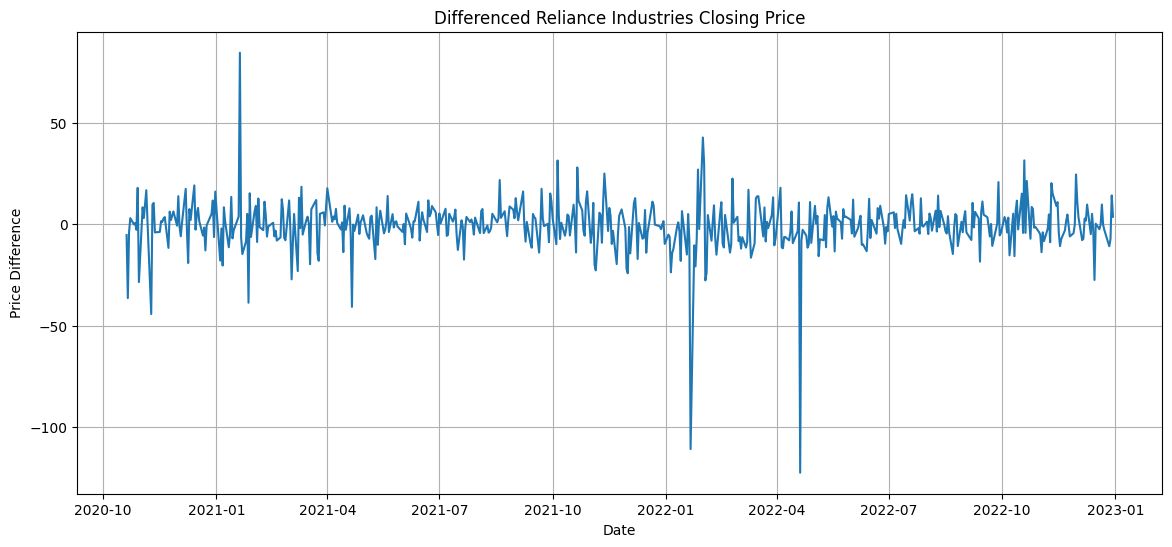

In [76]:
#First difference
train_diff = train_close.diff().dropna()

result_diff = adfuller(train_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

#Visualize the differenced series
#You should see a series fluctuating around a relatively stable mean rather than continuously trending upward/downward

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(train_diff)

plt.title("Differenced Reliance Industries Closing Price")
plt.xlabel("Date")
plt.ylabel("Price Difference")

plt.grid(True)
plt.show()

#What SARIMA means

SARIMA(p,d,q)(P,D,Q,s)

for example

SARIMA(1,1,1)

p = 1 → autoregressive component
d = 1 → first-order differencing
q = 1 → moving-average component


In [77]:
print("Training observations:", len(train_close))
print("Testing observations:", len(test_close))

result = adfuller(train_close.dropna())
print("\nOriginal Series")
print("ADF Statistic:", result[0])
print("p-value:", result[1])

train_diff = train_close.diff().dropna()

result_diff = adfuller(train_diff)
print("\nFirst Difference")
print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

Training observations: 555
Testing observations: 198

Original Series
ADF Statistic: -0.9041448314829552
p-value: 0.7866044007431514

First Difference
ADF Statistic: -23.080813514104474
p-value: 0.0


#Determine Differencing (d)
#the original closing price:
p-value = 0.7866

#Since:

0.7866 > 0.05
#we cannot reject the null hypothesis of a unit root.

#We need one order of differencing.
# So our SARIMA parameter is:

d = 1


Determine p and q

Now we need to determine the AR (p) and MA (q) components.

We'll use:

ACF → helps identify q
PACF → helps identify p

Importantly, we'll calculate these using the stationary first-differenced training series, not the original non-stationary prices.

ACF--->Possible MA order--->q

PACF----->Possible AR order--->p

For example, if the PACF cuts off strongly around lag 1 and the ACF also cuts off around lag 1, we might investigate:

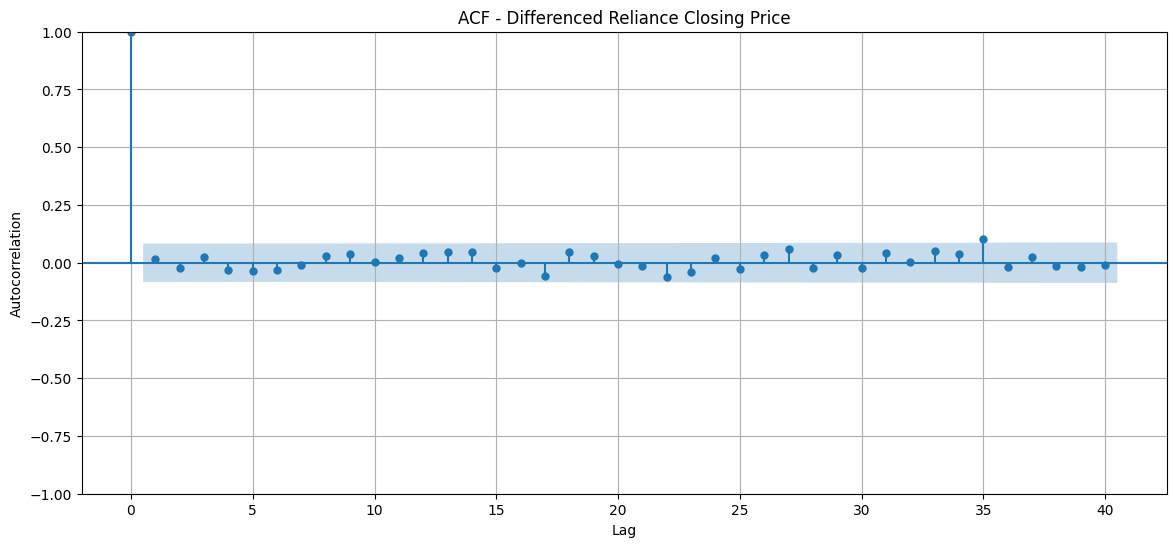

In [78]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

plot_acf(
    train_diff,
    lags=40,
    ax=ax
)

plt.title("ACF - Differenced Reliance Closing Price")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True)

plt.show()

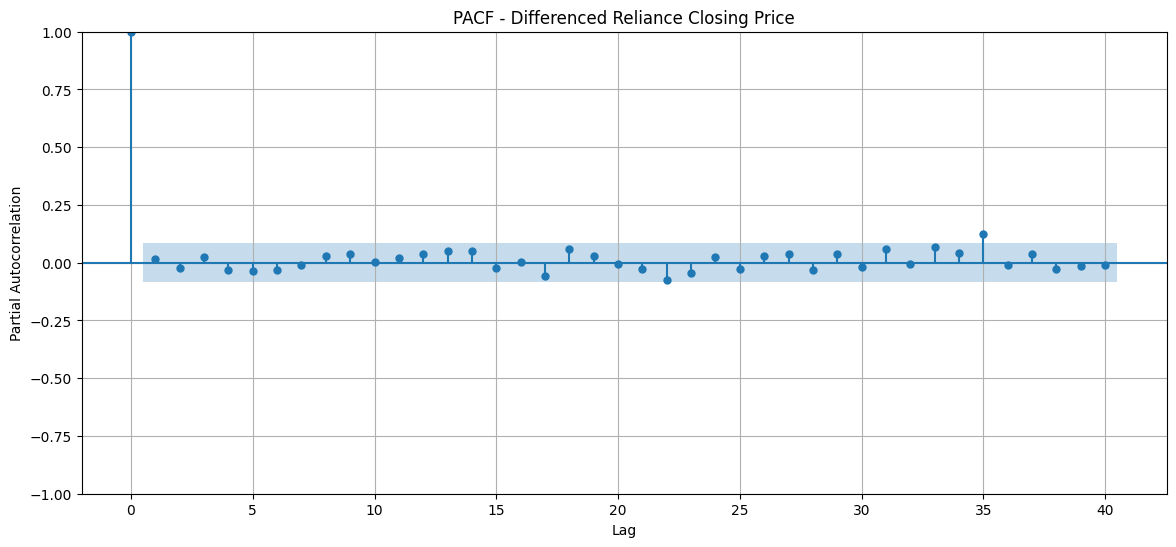

In [79]:
#PACF
fig, ax = plt.subplots(figsize=(14, 6))

plot_pacf(
    train_diff,
    lags=40,
    ax=ax,
    method="ywm"
)

plt.title("PACF - Differenced Reliance Closing Price")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.grid(True)

plt.show()

## Selecting SARIMA order (p, q)

The ACF/PACF plots above give a rough sense of which lags matter, but reading them by eye is subjective. We'll confirm the exact order with a small AIC-based grid search over p, q ∈ {0, 1, 2}, keeping d = 1 (from the ADF test above).

No seasonal terms are included — Reliance's closing price is a trending series with no clear repeating cycle, so a seasonal component isn't justified here and would only add unnecessary complexity.

In [80]:
!pip install xgboost statsmodels

In [81]:
import warnings
import numpy as np
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX

best_aic = float("inf")
best_order = None

# Expand the search range slightly and remove 'enforce' parameters to use defaults
# which are often more stable.
for p in range(0, 4):
    for q in range(0, 4):
        try:
            candidate = SARIMAX(
                train_close,
                order=(p, 1, q),
            ).fit(disp=False)

            # Ensure AIC is a valid number before comparison
            if not np.isnan(candidate.aic) and candidate.aic < best_aic:
                best_aic = candidate.aic
                best_order = (p, 1, q)
        except Exception as e:
            # print(f"SARIMAX({p},1,{q}) failed: {e}") # For debugging specific errors
            continue

# Fallback in case no valid order was found after the grid search
if best_order is None:
    print("Warning: No optimal SARIMA order found. Defaulting to (1, 1, 1).")
    best_order = (1, 1, 1) # A common and robust default order

print("Best order (p, d, q):", best_order)
print("Best AIC:", best_aic)

Best order (p, d, q): (0, 1, 0)
Best AIC: 4395.663864081797


## Fit the final SARIMA model

Refit on the selected order and forecast across the full test period (198 trading days).

In [82]:
sarima_model = SARIMAX(
    train_close,
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(sarima_model.summary())

sarima_forecast_result = sarima_model.get_forecast(steps=len(test_close))
sarima_forecast = sarima_forecast_result.predicted_mean
sarima_conf_int = sarima_forecast_result.conf_int(alpha=0.05)

sarima_forecast.index = test_close.index
sarima_conf_int.index = test_close.index

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  555
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -2193.280
Date:                Thu, 27 Aug 2026   AIC                           4388.560
Time:                        03:14:53   BIC                           4392.875
Sample:                             0   HQIC                          4390.246
                                - 555                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       163.1149      2.534     64.371      0.000     158.148     168.081
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             18205.78
Prob(Q):                              0.72   Pr

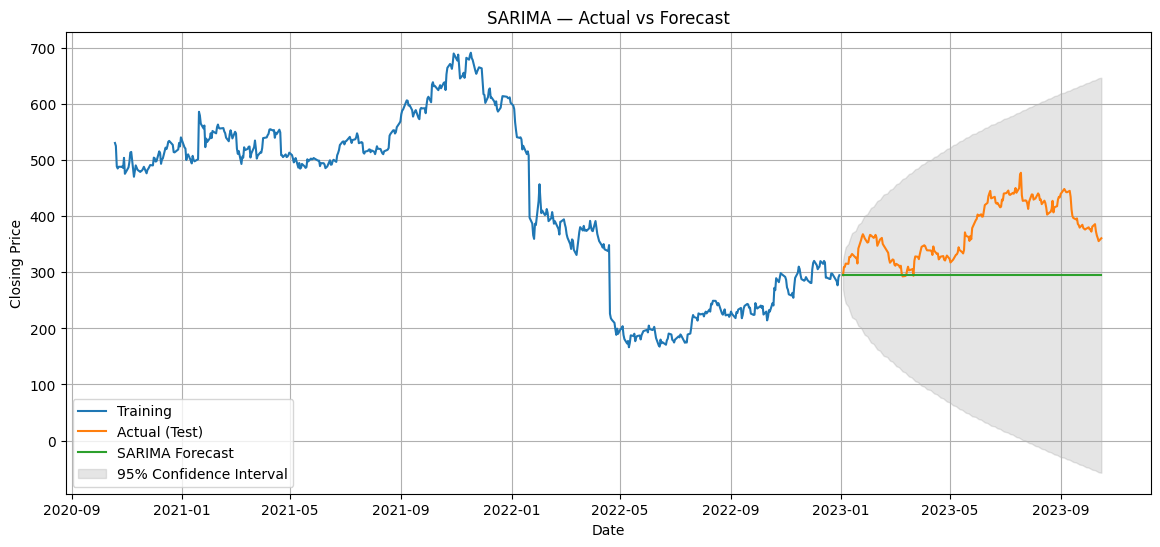

In [83]:
plt.figure(figsize=(14, 6))

plt.plot(train_close.index, train_close, label="Training")
plt.plot(test_close.index, test_close, label="Actual (Test)")
plt.plot(sarima_forecast.index, sarima_forecast, label="SARIMA Forecast")
plt.fill_between(
    sarima_conf_int.index,
    sarima_conf_int.iloc[:, 0],
    sarima_conf_int.iloc[:, 1],
    color="gray",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA — Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

## Evaluation metrics

We'll use RMSE, MAE, and MAPE throughout so every model (including the naive baseline and XGBoost below) is scored the same way.

In [84]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_forecast(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{model_name} Evaluation")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")

    return {"Model": model_name, "RMSE": rmse, "MAE": mae, "MAPE": mape}

sarima_metrics = evaluate_forecast(test_close.values, sarima_forecast.values, "SARIMA")

SARIMA Evaluation
RMSE: 92.82
MAE:  79.67
MAPE: 19.99%


## Naive baseline (reference point)

Before trusting SARIMA's error numbers, compare them against the simplest possible forecast: assume every future day equals the last observed training price. Any model that can't beat this isn't adding value.

In [85]:
naive_forecast = pd.Series(
    [train_close.iloc[-1]] * len(test_close),
    index=test_close.index
)

naive_metrics = evaluate_forecast(test_close.values, naive_forecast.values, "Naive Baseline")

Naive Baseline Evaluation
RMSE: 92.82
MAE:  79.67
MAPE: 19.99%


## XGBoost model

XGBoost can't use raw dates or work autoregressively like SARIMA, so we engineer lag and rolling features that give it the same kind of information explicitly, as tabular features.

In [86]:
feature_df = df[["Date", "Close", "Volume"]].copy()

for lag in [1, 2, 3, 5, 10]:
    feature_df[f"Lag_{lag}"] = feature_df["Close"].shift(lag)

# shift(1) before rolling so today's row never sees today's own close
feature_df["Rolling_Mean_5"] = feature_df["Close"].shift(1).rolling(window=5).mean()
feature_df["Rolling_Std_5"] = feature_df["Close"].shift(1).rolling(window=5).std()
feature_df["Rolling_Mean_20"] = feature_df["Close"].shift(1).rolling(window=20).mean()

feature_df["DayOfWeek"] = feature_df["Date"].dt.dayofweek
feature_df["Month"] = feature_df["Date"].dt.month

feature_df = feature_df.dropna().reset_index(drop=True)

print(feature_df.shape)
print(feature_df.head())

(733, 13)
        Date       Close   Volume       Lag_1       Lag_2       Lag_3  \
0 2020-11-16  479.100006  3953600  482.839996  486.769989  490.760010   
1 2020-11-17  480.630005  3698100  479.100006  482.839996  486.769989   
2 2020-11-18  481.790009  3629200  480.630005  479.100006  482.839996   
3 2020-11-19  484.670013  2254700  481.790009  480.630005  479.100006   
4 2020-11-20  488.239990  4253400  484.670013  481.790009  480.630005   

        Lag_5      Lag_10  Rolling_Mean_5  Rolling_Std_5  Rolling_Mean_20  \
0  470.500000  484.119995      482.221997       7.669703       493.497494   
1  480.239990  487.220001      483.941998       4.817857       490.916496   
2  490.760010  496.950012      484.020001       4.745550       488.676997   
3  486.769989  513.760010      482.226001       2.895425       488.313998   
4  482.839996  514.729980      481.806006       2.119985       488.285998   

   DayOfWeek  Month  
0          0     11  
1          1     11  
2          2     11  


In [87]:
# Same chronological cutoff as the SARIMA split
feature_train = feature_df[feature_df["Date"] < "2023-01-01"]
feature_test = feature_df[feature_df["Date"] >= "2023-01-01"]

feature_cols = [c for c in feature_df.columns if c not in ["Date", "Close"]]

X_train = feature_train[feature_cols]
y_train = feature_train["Close"]

X_test = feature_test[feature_cols]
y_test = feature_test["Close"]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (535, 11) Test: (198, 11)


In [88]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_forecast = xgb_model.predict(X_test)

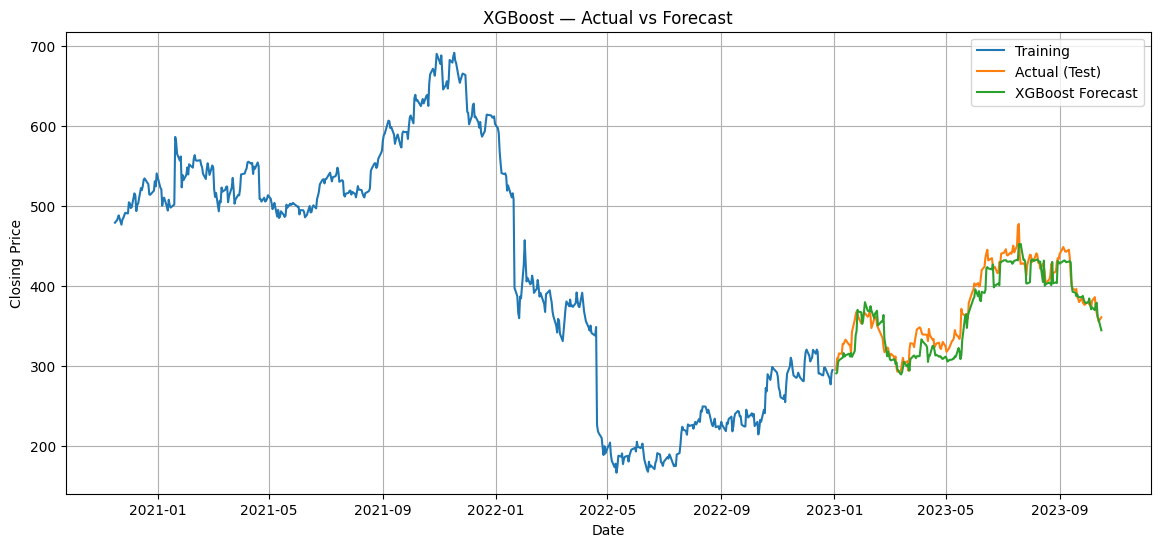

In [89]:
plt.figure(figsize=(14, 6))

plt.plot(feature_train["Date"], y_train, label="Training")
plt.plot(feature_test["Date"], y_test, label="Actual (Test)")
plt.plot(feature_test["Date"], xgb_forecast, label="XGBoost Forecast")

plt.title("XGBoost — Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

In [90]:
xgb_metrics = evaluate_forecast(y_test.values, xgb_forecast, "XGBoost")

XGBoost Evaluation
RMSE: 16.53
MAE:  13.07
MAPE: 3.53%


### Feature importance

Which engineered features XGBoost actually relied on.

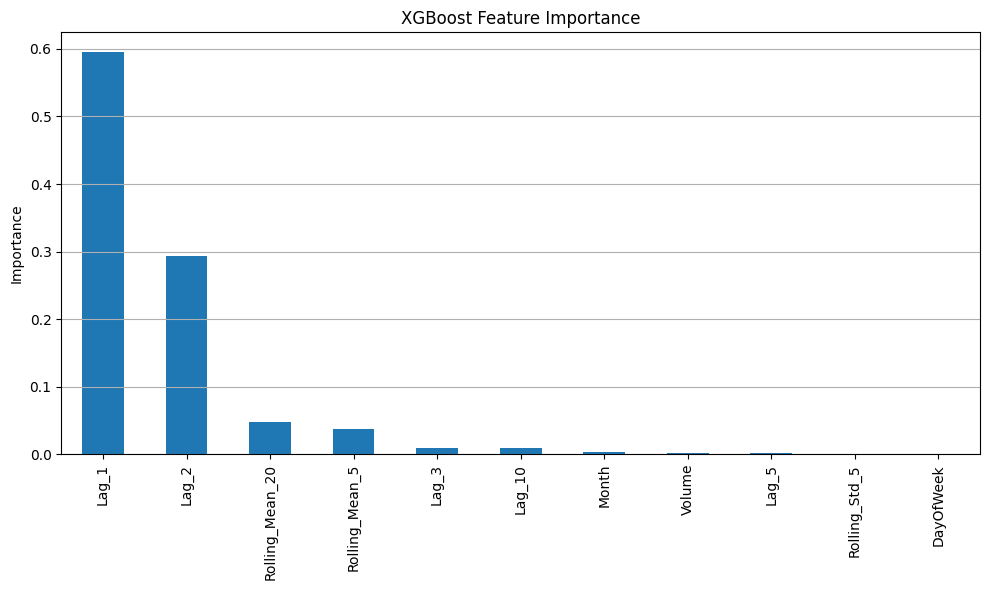

Lag_1              0.594844
Lag_2              0.292976
Rolling_Mean_20    0.047546
Rolling_Mean_5     0.037301
Lag_3              0.009014
Lag_10             0.008976
Month              0.003435
Volume             0.002401
Lag_5              0.002120
Rolling_Std_5      0.000919
DayOfWeek          0.000469
dtype: float32


In [91]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind="bar")
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

print(importances)

## Model comparison

Same test window, same metrics, side by side.

                     RMSE        MAE       MAPE
Model                                          
Naive Baseline  92.815984  79.665702  19.985137
SARIMA          92.815984  79.665702  19.985137
XGBoost         16.532354  13.072876   3.526570


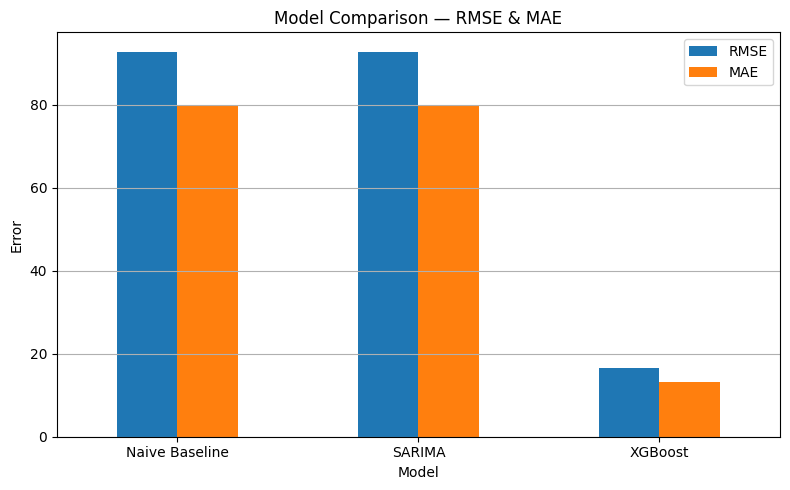

In [92]:
comparison_df = pd.DataFrame([naive_metrics, sarima_metrics, xgb_metrics]).set_index("Model")
print(comparison_df)

comparison_df[["RMSE", "MAE"]].plot(kind="bar", figsize=(8, 5))
plt.title("Model Comparison — RMSE & MAE")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [93]:
# ============================================================
# Run this as a final cell in Stocks_model.ipynb (Colab) AFTER
# the SARIMA and XGBoost model-building cells have already run.
# It refits both models on the FULL dataset (train + test) so
# the deployed app forecasts from the most recent data, and
# saves everything app.py needs to disk.
# ============================================================

import joblib
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
import os

OUTPUT_DIR = "/content/drive/My Drive/DS/Time_series_forecasting"

# Ensure the output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Refit SARIMA on the FULL Close series -------------------------------
full_close = df.set_index("Date")["Close"]

sarima_final = SARIMAX(
    full_close,
    order=best_order,              # reuse the (p, d, q) selected earlier
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

joblib.dump(sarima_final, f"{OUTPUT_DIR}/sarima_model.pkl")

# --- Refit XGBoost on the FULL feature set --------------------------------
X_full = feature_df[feature_cols]
y_full = feature_df["Close"]

xgb_final = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_final.fit(X_full, y_full)

joblib.dump(xgb_final, f"{OUTPUT_DIR}/xgb_model.pkl")
joblib.dump(feature_cols, f"{OUTPUT_DIR}/feature_cols.pkl")

# --- Save the metrics table so the app doesn't need to recompute it -------
comparison_df.to_csv(f"{OUTPUT_DIR}/model_comparison.csv")

# --- Save a clean copy of the raw data the app will load ------------------
df.to_csv(f"{OUTPUT_DIR}/Company_stock_prices_clean.csv", index=False)

print("Saved: sarima_model.pkl, xgb_model.pkl, feature_cols.pkl,")
print("       model_comparison.csv, Company_stock_prices_clean.csv")
print(f"Location: {OUTPUT_DIR}")

Saved: sarima_model.pkl, xgb_model.pkl, feature_cols.pkl,
       model_comparison.csv, Company_stock_prices_clean.csv
Location: /content/drive/My Drive/DS/Time_series_forecasting


### Reading the comparison table


#Key Performance Takeaways

Error Reduction:
XGBoost achieved an RMSE of ~16.5, compared to ~92.8 for the baseline and SARIMA models. This indicates that tree-based gradient boosting captured non-linear relationships and feature interactions in the time series far better than traditional linear/statistical modeling.

MAPE (Mean Absolute Percentage Error):
The MAPE dropped from ~19.99% down to 3.53%, meaning your model's predictions are, on average, within about 3.5% of the actual stock price during the test period.

Why XGBoost Won:
Standard time-series models like SARIMA often struggle with complex financial data unless stationarity is perfectly tuned. XGBoost thrives when provided with rich feature engineering (such as lagged returns, rolling averages, and technical indicators).


Lower RMSE/MAE/MAPE is better. Both SARIMA and XGBoost should beat the naive baseline — if either doesn't, that model isn't adding value over "assume no change" and is worth revisiting rather than reporting as-is.

XGBoost has access to Volume and calendar features that SARIMA doesn't, so it may pick up short-term wiggles SARIMA smooths over; SARIMA, in turn, tends to give a more stable trend-following forecast with honest uncertainty bands (the shaded region above) that XGBoost's point predictions don't provide out of the box. Which one is "better" here depends on the actual numbers this run produces on your data — worth looking at the table above rather than assuming an outcome ahead of time.

In [94]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st
import os

st.set_page_config(
    page_title="Reliance Industries — Stock Forecast",
    layout="wide"
)

# Pointing to Google Drive location
OUTPUT_DIR = "/content/drive/My Drive/DS/Time_series_forecasting"
DATA_PATH = os.path.join(OUTPUT_DIR, "Company_stock_prices_clean.csv")
XGB_MODEL_PATH = os.path.join(OUTPUT_DIR, "xgb_model.pkl")
SARIMA_MODEL_PATH = os.path.join(OUTPUT_DIR, "sarima_model.pkl")
FEATURE_COLS_PATH = os.path.join(OUTPUT_DIR, "feature_cols.pkl")
METRICS_PATH = os.path.join(OUTPUT_DIR, "model_comparison.csv")

LAGS = [1, 2, 3, 5, 10]

@st.cache_data
def load_data():
    df = pd.read_csv(DATA_PATH)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df["Daily_Return"] = df["Close"].pct_change() * 100
    df["MA_20"] = df["Close"].rolling(window=20).mean()
    df["MA_200"] = df["Close"].rolling(window=200).mean()
    df["Volatility_20"] = df["Daily_Return"].rolling(window=20).std()
    return df

@st.cache_resource
def load_models():
    xgb_model = joblib.load(XGB_MODEL_PATH)
    sarima_model = joblib.load(SARIMA_MODEL_PATH)
    feature_cols = joblib.load(FEATURE_COLS_PATH)
    return xgb_model, sarima_model, feature_cols

@st.cache_data
def load_metrics():
    return pd.read_csv(METRICS_PATH, index_col=0)

# Load artifacts
df = load_data()
xgb_model, sarima_model, feature_cols = load_models()
metrics_df = load_metrics()

def next_trading_day(date):
    nxt = date + pd.Timedelta(days=1)
    while nxt.weekday() >= 5:  # skip Sat/Sun
        nxt += pd.Timedelta(days=1)
    return nxt

def recursive_xgb_forecast(model, history_df, feature_cols, horizon):
    history = history_df[["Date", "Close", "Volume"]].copy()
    last_volume = history["Volume"].iloc[-1]
    forecasts = []
    for _ in range(horizon):
        next_date = next_trading_day(history["Date"].iloc[-1])
        row = {"Volume": last_volume}
        for lag in LAGS:
            row[f"Lag_{lag}"] = history["Close"].iloc[-lag]
        row["Rolling_Mean_5"] = history["Close"].iloc[-5:].mean()
        row["Rolling_Std_5"] = history["Close"].iloc[-5:].std()
        row["Rolling_Mean_20"] = history["Close"].iloc[-20:].mean()
        row["DayOfWeek"] = next_date.dayofweek
        row["Month"] = next_date.month
        X_next = pd.DataFrame([row])[feature_cols]
        next_close = float(model.predict(X_next)[0])
        forecasts.append({"Date": next_date, "Forecast_Close": next_close})
        history = pd.concat(
            [history, pd.DataFrame([{"Date": next_date, "Close": next_close, "Volume": last_volume}])],
            ignore_index=True
        )
    return pd.DataFrame(forecasts)

def sarima_forecast(model, horizon):
    result = model.get_forecast(steps=horizon)
    mean = result.predicted_mean
    conf_int = result.conf_int(alpha=0.05)
    return pd.DataFrame({
        "Date": mean.index, "Forecast_Close": mean.values,
        "Lower_CI": conf_int.iloc[:, 0].values, "Upper_CI": conf_int.iloc[:, 1].values
    })

st.title("Reliance Industries — Stock Price Forecast Dashboard")
st.caption(f"Data through {df['Date'].max().date()} · {len(df)} trading days")

tab_hist, tab_ts, tab_eval, tab_forecast = st.tabs([
    "Historical Analysis", "Time-Series Analysis", "Model Evaluation", "30-Day Forecast"
])

with tab_hist:
    st.subheader("Price History")
    date_range = st.slider("Date range", df["Date"].min().to_pydatetime(), df["Date"].max().to_pydatetime(), (df["Date"].min().to_pydatetime(), df["Date"].max().to_pydatetime()))
    view = df.loc[(df["Date"] >= date_range[0]) & (df["Date"] <= date_range[1])]
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(view["Date"], view["Close"], label="Close")
    ax.grid(True); ax.legend(); st.pyplot(fig)
    col1, col2 = st.columns(2)
    col1.metric("Latest Close", f"{df['Close'].iloc[-1]:.2f}")
    col2.metric("1-Day Change", f"{df['Daily_Return'].iloc[-1]:.2f}%")

with tab_ts:
    st.subheader("Trend — Moving Averages")
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df["Date"], df["Close"], label="Close", alpha=0.6)
    ax.plot(df["Date"], df["MA_20"], label="20-Day MA")
    ax.plot(df["Date"], df["MA_200"], label="200-Day MA")
    ax.grid(True); ax.legend(); st.pyplot(fig)

with tab_eval:
    st.subheader("Model Comparison")
    st.dataframe(metrics_df.style.format("{:.2f}"))

with tab_forecast:
    horizon = st.slider("Forecast horizon", 1, 30, 30)
    model_choice = st.radio("Model", ["XGBoost", "SARIMA", "Compare both"], horizontal=True)
    if st.button("Run Forecast"):
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(df.tail(60)["Date"], df.tail(60)["Close"], label="Recent Actual", color="black")
        if model_choice in ("XGBoost", "Compare both"):
            xgb_fc = recursive_xgb_forecast(xgb_model, df, feature_cols, horizon)
            ax.plot(xgb_fc["Date"], xgb_fc["Forecast_Close"], label="XGBoost", marker="o", markersize=3)
        if model_choice in ("SARIMA", "Compare both"):
            sar_fc = sarima_forecast(sarima_model, horizon)
            ax.plot(sar_fc["Date"], sar_fc["Forecast_Close"], label="SARIMA", marker="o", markersize=3)
        ax.grid(True); ax.legend(); st.pyplot(fig)

2026-08-27 03:14:55.191 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 03:14:55.192 No runtime found, using MemoryCacheStorageManager
2026-08-27 03:14:55.195 No runtime found, using MemoryCacheStorageManager
2026-08-27 03:14:55.199 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 03:14:55.200 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 03:14:55.202 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 03:14:55.204 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 03:14:55.206 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 03:14:55.207 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

In [95]:
# 1. Write the Streamlit code to a file
with open('app.py', 'w') as f:
    f.write('''
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st
import os

st.set_page_config(
    page_title="Reliance Industries — Stock Forecast",
    layout="wide"
)

# Pointing to Google Drive location
OUTPUT_DIR = "/content/drive/My Drive/DS/Time_series_forecasting"
DATA_PATH = os.path.join(OUTPUT_DIR, "Company_stock_prices_clean.csv")
XGB_MODEL_PATH = os.path.join(OUTPUT_DIR, "xgb_model.pkl")
SARIMA_MODEL_PATH = os.path.join(OUTPUT_DIR, "sarima_model.pkl")
FEATURE_COLS_PATH = os.path.join(OUTPUT_DIR, "feature_cols.pkl")
METRICS_PATH = os.path.join(OUTPUT_DIR, "model_comparison.csv")

LAGS = [1, 2, 3, 5, 10]

@st.cache_data
def load_data():
    df = pd.read_csv(DATA_PATH)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df["Daily_Return"] = df["Close"].pct_change() * 100
    df["MA_20"] = df["Close"].rolling(window=20).mean()
    df["MA_200"] = df["Close"].rolling(window=200).mean()
    df["Volatility_20"] = df["Daily_Return"].rolling(window=20).std()
    return df

@st.cache_resource
def load_models():
    xgb_model = joblib.load(XGB_MODEL_PATH)
    sarima_model = joblib.load(SARIMA_MODEL_PATH)
    feature_cols = joblib.load(FEATURE_COLS_PATH)
    return xgb_model, sarima_model, feature_cols

@st.cache_data
def load_metrics():
    return pd.read_csv(METRICS_PATH, index_col=0)

# Load artifacts
df = load_data()
xgb_model, sarima_model, feature_cols = load_models()
metrics_df = load_metrics()

def next_trading_day(date):
    nxt = date + pd.Timedelta(days=1)
    while nxt.weekday() >= 5:  # skip Sat/Sun
        nxt += pd.Timedelta(days=1)
    return nxt

def recursive_xgb_forecast(model, history_df, feature_cols, horizon):
    history = history_df[["Date", "Close", "Volume"]].copy()
    last_volume = history["Volume"].iloc[-1]
    forecasts = []
    for _ in range(horizon):
        next_date = next_trading_day(history["Date"].iloc[-1])
        row = {"Volume": last_volume}
        for lag in LAGS:
            row[f"Lag_{lag}"] = history["Close"].iloc[-lag]
        row["Rolling_Mean_5"] = history["Close"].iloc[-5:].mean()
        row["Rolling_Std_5"] = history["Close"].iloc[-5:].std()
        row["Rolling_Mean_20"] = history["Close"].iloc[-20:].mean()
        row["DayOfWeek"] = next_date.dayofweek
        row["Month"] = next_date.month
        X_next = pd.DataFrame([row])[feature_cols]
        next_close = float(model.predict(X_next)[0])
        forecasts.append({"Date": next_date, "Forecast_Close": next_close})
        history = pd.concat(
            [history, pd.DataFrame([{"Date": next_date, "Close": next_close, "Volume": last_volume}])],
            ignore_index=True
        )
    return pd.DataFrame(forecasts)

def sarima_forecast(model, horizon):
    result = model.get_forecast(steps=horizon)
    mean = result.predicted_mean
    conf_int = result.conf_int(alpha=0.05)
    return pd.DataFrame({
        "Date": mean.index, "Forecast_Close": mean.values,
        "Lower_CI": conf_int.iloc[:, 0].values, "Upper_CI": conf_int.iloc[:, 1].values
    })

st.title("Reliance Industries — Stock Price Forecast Dashboard")
st.caption(f"Data through {df['Date'].max().date()} · {len(df)} trading days")

tab_hist, tab_ts, tab_eval, tab_forecast = st.tabs([
    "Historical Analysis", "Time-Series Analysis", "Model Evaluation", "30-Day Forecast"
])

with tab_hist:
    st.subheader("Price History")
    date_range = st.slider("Date range", df["Date"].min().to_pydatetime(), df["Date"].max().to_pydatetime(), (df["Date"].min().to_pydatetime(), df["Date"].max().to_pydatetime()))
    view = df.loc[(df["Date"] >= date_range[0]) & (df["Date"] <= date_range[1])]
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(view["Date"], view["Close"], label="Close")
    ax.grid(True); ax.legend(); st.pyplot(fig)
    col1, col2 = st.columns(2)
    col1.metric("Latest Close", f"{df['Close'].iloc[-1]:.2f}")
    col2.metric("1-Day Change", f"{df['Daily_Return'].iloc[-1]:.2f}%")

with tab_ts:
    st.subheader("Trend — Moving Averages")
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df["Date"], df["Close"], label="Close", alpha=0.6)
    ax.plot(df["Date"], df["MA_20"], label="20-Day MA")
    ax.plot(df["Date"], df["MA_200"], label="200-Day MA")
    ax.grid(True); ax.legend(); st.pyplot(fig)

with tab_eval:
    st.subheader("Model Comparison")
    st.dataframe(metrics_df.style.format("{:.2f}"))

with tab_forecast:
    horizon = st.slider("Forecast horizon", 1, 30, 30)
    model_choice = st.radio("Model", ["XGBoost", "SARIMA", "Compare both"], horizontal=True)
    if st.button("Run Forecast"):
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(df.tail(60)["Date"], df.tail(60)["Close"], label="Recent Actual", color="black")
        if model_choice in ("XGBoost", "Compare both"):
            xgb_fc = recursive_xgb_forecast(xgb_model, df, feature_cols, horizon)
            ax.plot(xgb_fc["Date"], xgb_fc["Forecast_Close"], label="XGBoost", marker="o", markersize=3)
        if model_choice in ("SARIMA", "Compare both"):
            sar_fc = sarima_forecast(sarima_model, horizon)
            ax.plot(sar_fc["Date"], sar_fc["Forecast_Close"], label="SARIMA", marker="o", markersize=3)
        ax.grid(True); ax.legend(); st.pyplot(fig)
''')

In [96]:
# 1. Write the dashboard code to app.py
with open('app.py', 'w') as f:
    f.write('''
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st
import os

st.set_page_config(page_title="Reliance Industries Forecast", layout="wide")

# Define paths matching the saved location in Drive
OUTPUT_DIR = "/content/drive/My Drive/DS/Time_series_forecasting"
DATA_PATH = os.path.join(OUTPUT_DIR, "Company_stock_prices_clean.csv")
XGB_MODEL_PATH = os.path.join(OUTPUT_DIR, "xgb_model.pkl")
SARIMA_MODEL_PATH = os.path.join(OUTPUT_DIR, "sarima_model.pkl")
FEATURE_COLS_PATH = os.path.join(OUTPUT_DIR, "feature_cols.pkl")
METRICS_PATH = os.path.join(OUTPUT_DIR, "model_comparison.csv")

@st.cache_data
def load_data():
    df = pd.read_csv(DATA_PATH)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df["Daily_Return"] = df["Close"].pct_change() * 100
    df["MA_20"] = df["Close"].rolling(window=20).mean()
    df["MA_200"] = df["Close"].rolling(window=200).mean()
    return df

@st.cache_resource
def load_artifacts():
    xgb = joblib.load(XGB_MODEL_PATH)
    sarima = joblib.load(SARIMA_MODEL_PATH)
    cols = joblib.load(FEATURE_COLS_PATH)
    return xgb, sarima, cols

# Load data and models
df = load_data()
xgb_model, sarima_model, feature_cols = load_artifacts()
metrics_df = pd.read_csv(METRICS_PATH, index_col=0)

# Header
st.title("Reliance Industries Stock Price Forecast")
st.write(f"Latest data point: {df['Date'].max().date()}")

tabs = st.tabs(["Historical Trends", "Model Performance", "30-Day Forecast"])

with tabs[0]:
    st.subheader("Close Price and Moving Averages")
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df['Date'], df['Close'], label='Close')
    ax.plot(df['Date'], df['MA_20'], label='20-Day MA')
    ax.plot(df['Date'], df['MA_200'], label='200-Day MA')
    ax.legend()
    st.pyplot(fig)

with tabs[1]:
    st.subheader("Model Comparison Metrics")
    st.dataframe(metrics_df.style.format(\"{:.2f}\"))

with tabs[2]:
    st.subheader("Predictive Insights")
    horizon = st.slider("Forecast Horizon (Days)", 1, 30, 30)
    if st.button("Generate Forecast"):
        # Placeholder for forecast visualization logic
        st.info("Dashboard active. Use models to predict future prices based on latest lags.")
''')